# Felony Arrest and Crime Incidents - EDA 
## Author: Martin Ngoh 
### Date: 10/10/2024

In [1]:
# Load Packages 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Data 
dfOrig = pd.read_csv('../data/combined_cleaned_data.csv')
dfOrig.head(2)
dfOrig.columns

Index(['objectid', 'mpd_arrest_number', 'mpd_arrest_date',
       'mpd_charge_category', 'mpd_charge_description', 'charge_code', 'age',
       'arrest_count', 'race', 'ethnicity', 'sex', 'home_psa',
       'arrest_district', 'arrest_psa', 'home_city', 'home_state', 'pdid',
       'ccn', 'latitude', 'longitude', 'dmpsj_category', 'month',
       'is_marijuana', 'globalid', 'offense_report_date', 'profile_type',
       'offense_category', 'offense_description', 'offense_location_district',
       'offense_location_psa'],
      dtype='object')

In [3]:
# Subset the Data 
df = dfOrig[['mpd_charge_category', 'mpd_arrest_date', 'charge_code', 'age', 'race', 'home_state', \
         'home_city', 'is_marijuana', 'offense_location_district', 'arrest_count']]

In [4]:
# Rename Columns
df = df.rename(columns = {
    'mpd_charge_category': 'charge_category',
    'mpd_arrest_date':'arrest_date',
    'offense_location_district':'district'
})

In [5]:
# Convert Datetime to month and time 
df['arrest_date'] = pd.to_datetime(df['arrest_date'])
df['month'] = df['arrest_date'].dt.month
df['hour'] = df['arrest_date'].dt.hour

In [6]:
# Look at Race Category
df.groupby('race')['age'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
American Indian Or Alaska Native,2.0,19.00,0.00,19.0,19.0,19.0,19.0,19.0
Asian,36.0,35.61,9.70,18.0,28.0,38.5,45.0,51.0
Black,19070.0,32.06,11.98,18.0,22.0,28.0,39.0,81.0
Native Hawaiian Or Other Pacific Islander,10.0,36.60,10.51,25.0,26.0,37.0,45.0,50.0
Unknown,392.0,28.86,9.80,18.0,22.0,25.0,32.0,62.0
White,1376.0,34.52,12.83,18.0,24.0,32.0,44.0,80.0


In [7]:
# Look at Charge Category
df.groupby('charge_category')['race'].describe().round(2)

,count,unique,top,freq
charge_category,,,,
Aggravated Assault,503,5,Black,402
Arson,7,1,Black,7
Assault on a Police Officer,255,3,Black,213
Assault with a Dangerous Weapon,2561,5,Black,2302
Burglary,644,3,Black,583
Damage to Property,308,3,Black,257
Disorderly Conduct,2,1,Black,2
Driving/Boating While Intoxicated,24,2,Black,20
Fraud and Financial Crimes,214,3,Black,180


In [8]:
# Look at Charge Category
df.groupby('district')['race'].describe().round(2)

,count,unique,top,freq
district,,,,
1D,4859,5,Black,4411
2D,964,4,Black,647
3D,2012,5,Black,1655
4D,1884,5,Black,1441
5D,3974,4,Black,3845
6D,3400,4,Black,3328
7D,3778,3,Black,3728
Unknown,15,1,Black,15


In [9]:
# Weapons Df
weaponDf = df[df['charge_category'] == 'Weapon Violations']
weaponDf.describe()

,arrest_date,age,arrest_count,month,hour
count,3963,3963.000000,3963.00000,3963.000000,3963.000000
mean,2016-07-24 03:17:13.656321024,27.309866,5.30810,7.246278,14.589957
min,2016-01-01 01:00:00,18.000000,0.00000,1.000000,0.000000
25%,2016-04-28 08:28:00,21.000000,1.00000,4.000000,10.000000
50%,2016-07-27 18:42:00,24.000000,4.00000,7.000000,18.000000
75%,2016-10-26 20:10:00,31.000000,8.00000,10.000000,20.000000
max,2016-12-31 22:36:00,80.000000,39.00000,12.000000,23.000000
std,NaN,9.250312,5.07423,3.401815,7.447624


In [10]:
# Homicide Df
homicide = df[df['charge_category'] == 'Homicide']
homicide.describe()

,arrest_date,age,arrest_count,month,hour
count,138,138.000000,138.000000,138.000000,138.000000
mean,2016-07-14 13:10:11.739130368,30.550725,5.775362,6.869565,12.057971
min,2016-01-22 10:00:00,18.000000,0.000000,1.000000,0.000000
25%,2016-04-12 16:56:15,24.000000,2.000000,4.000000,9.000000
50%,2016-08-02 13:00:00,28.500000,5.000000,8.000000,12.000000
75%,2016-10-18 14:03:45,35.000000,9.000000,10.000000,15.750000
max,2016-12-31 09:30:00,67.000000,25.000000,12.000000,23.000000
std,NaN,10.482570,4.673294,3.419195,5.403119


In [11]:
# Arrest Count 
df.groupby('race')['arrest_count'].mean()

race
American Indian Or Alaska Native             2.000000
Asian                                        7.777778
Black                                        7.161196
Native Hawaiian Or Other Pacific Islander    0.200000
Unknown                                      2.966837
White                                        4.800872
Name: arrest_count, dtype: float64

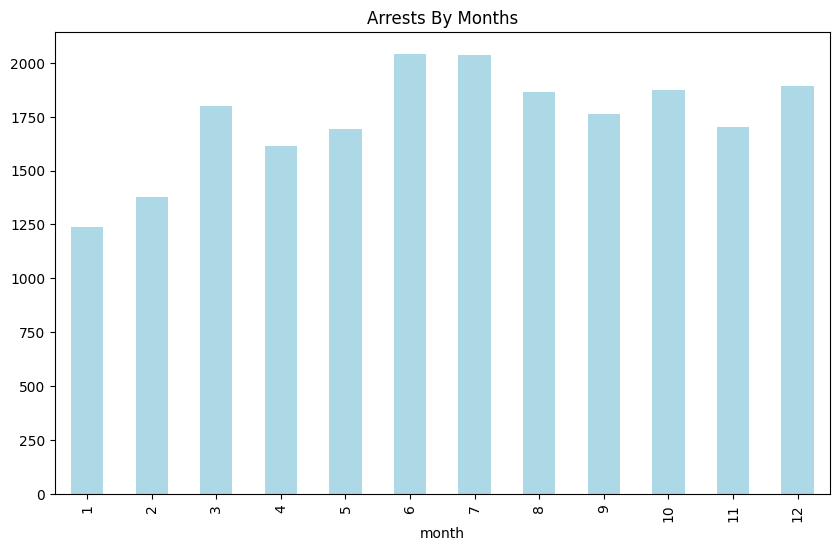

In [12]:
# Group by 'arrest_date' and count the number of arrests
df.groupby('month').size().plot(kind='bar', figsize=(10, 6), color='lightblue')
plt.title('Arrests By Months')
plt.show()

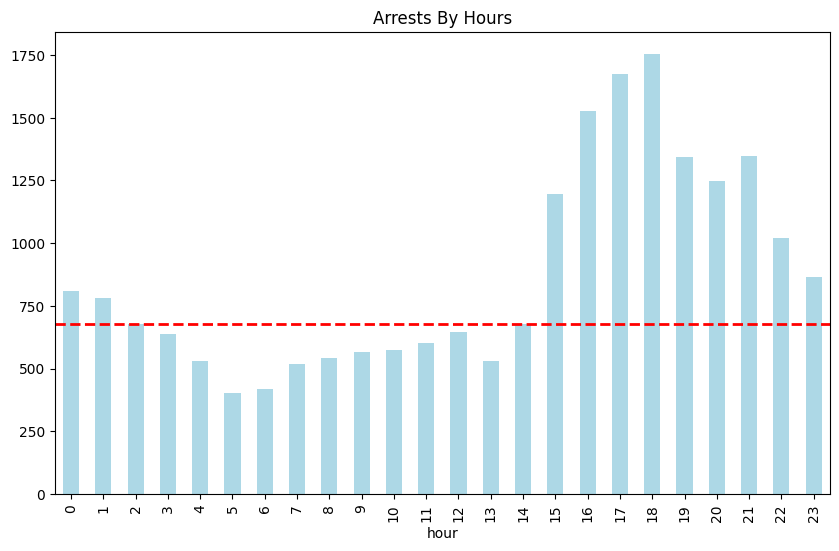

In [20]:
# Group by 'arrest_date' and count the number of arrests
mean_value = df.groupby('hour').size().median()
df.groupby('hour').size().plot(kind='bar', figsize=(10, 6), color='lightblue')
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
plt.title('Arrests By Hours')
plt.show()

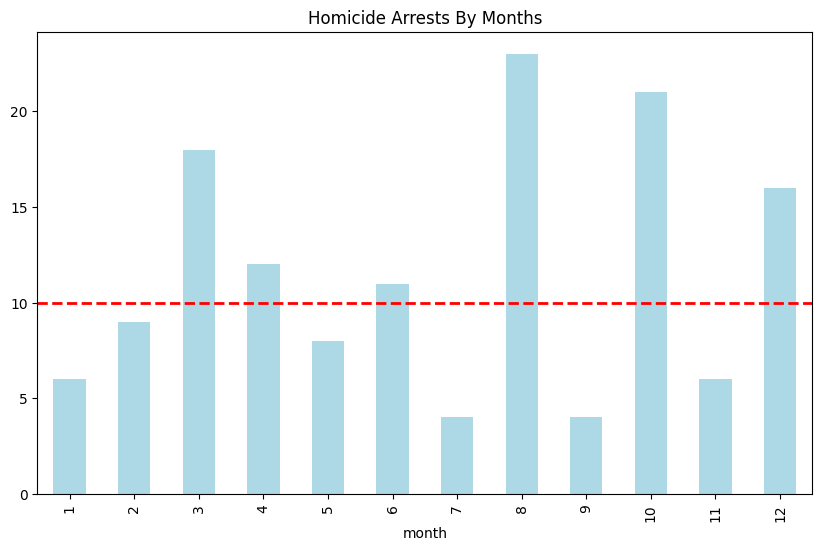

In [18]:
# Look at homicides by month
mean_value = homicide.groupby('month').size().median()
homicide.groupby('month').size().plot(kind='bar', figsize=(10, 6), color='lightblue')
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
plt.title('Homicide Arrests By Months')
plt.show()

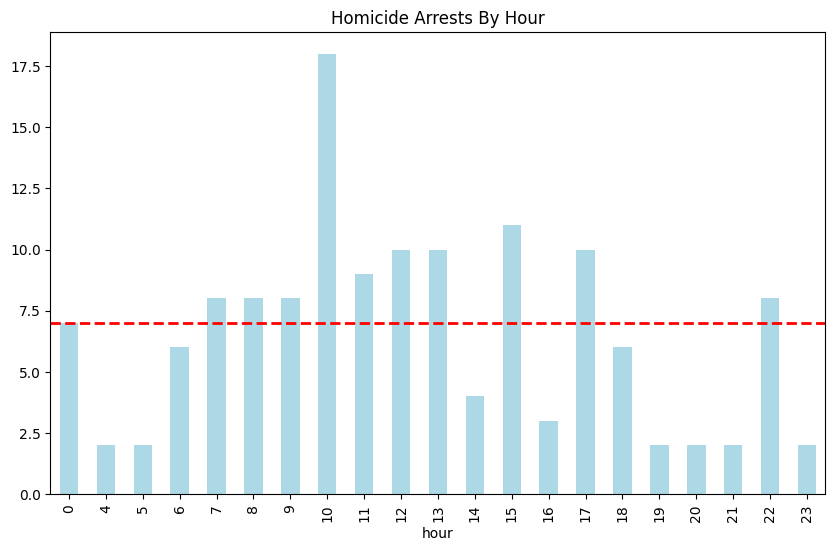

In [19]:
# Look at homicides by HOUR
mean_value = homicide.groupby('hour').size().median()
homicide.groupby('hour').size().plot(kind='bar', figsize=(10, 6), color='lightblue')
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
plt.title('Homicide Arrests By Hour')
plt.show()

In [71]:
# Percent of Black People in the Dataset


In [80]:
# Look at Proportion of Black People to Arrest Category
constant = round(len(df[df['race'] == 'Black']) / len(df), 2)
black = df[df['race'] == 'Black']
print('White %', constant)
total_counts = df.groupby('charge_category').size().reset_index(name='total_count')
black_counts = black.groupby('charge_category').size().reset_index(name='black_count')
merged_counts = pd.merge(black_counts, total_counts, on='charge_category')
merged_counts['normalized_count'] = merged_counts['black_count'] / merged_counts['total_count']
merged_counts['higher'] = merged_counts['normalized_count'] > 2*constant

White % 0.91


In [81]:
merged_counts[merged_counts['higher']==True]

,charge_category,black_count,total_count,normalized_count,higher


In [82]:
# Look at Proportion of Black People to Arrest Category
constant = round(len(df[df['race'] == 'White']) / len(df), 4)
print('White %', constant)
black = df[df['race'] == 'White']
total_counts = df.groupby('charge_category').size().reset_index(name='total_count')
black_counts = black.groupby('charge_category').size().reset_index(name='white_count')
merged_counts = pd.merge(black_counts, total_counts, on='charge_category')
merged_counts['normalized_count'] = merged_counts['white_count'] / merged_counts['total_count']
merged_counts['higher'] = merged_counts['normalized_count'] > 2*constant

White % 0.0659


In [83]:
merged_counts[merged_counts['higher']==True]

,charge_category,white_count,total_count,normalized_count,higher
0,Aggravated Assault,70,503,0.139165,True
4,Damage to Property,43,308,0.139610,True
5,Driving/Boating While Intoxicated,4,24,0.166667,True
13,Prostitution,10,23,0.434783,True
16,Sex Abuse,40,189,0.211640,True
17,Sex Offenses,65,181,0.359116,True
